<a href="https://colab.research.google.com/github/algroznykh/notebooks/blob/master/dor_chladni_nca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import cv2
import time


def dor(shader_func, res=128, fps_limit=60, stop=None):
    """dynamic online renderer for jupyter"""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    img_widget = widgets.Image(format='jpeg', width=res, height=res)
    fps_label = widgets.Label(value="Initializing...")

    ui = widgets.VBox([
        img_widget,
        fps_label
    ])
    display(ui)

    t = 0.0
    dt = 1.0 / fps_limit
    start_time = time.time()

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 100]

    frame_count = 0

    try:
      while True:
        loop_start = time.time()
        with torch.no_grad():
          img_tensor = shader_func(res, t)
          img_tensor = (img_tensor.clamp(0, 1) * 255).byte()
          img_np = img_tensor.cpu().numpy()
        if img_np.shape[-1] == 3: img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        elif img_np.shape[-1] == 4: img_np = cv2.cvtColor(img_np, cv2.COLOR_RGBA2BGR)

        _, enc_data = cv2.imencode('.jpg', img_np, encode_param)
        img_widget.value = enc_data.tobytes()

        frame_count += 1
        t += dt
        if stop is not None and frame_count >= stop:
          break
        process_time = time.time() - loop_start
        if process_time > 0: fps_label.value = f"FPS: {1.0/process_time:.1f} | t={t:.2f}"

        wait = dt - process_time
        if wait > 0: time.sleep(wait)

    except KeyboardInterrupt:
      fps_label.value = "Stopped."

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl


def set_dark_mode():
    """matplotlib dark mode"""
    plt.style.use('dark_background')

    dark_bg = '#121212'
    text_color = '#E0E0E0'
    grid_color = '#303030'
    accent_color = '#BB86FC'

    mpl.rcParams.update({
        'figure.facecolor': dark_bg,
        'axes.facecolor': dark_bg,

        'text.color': text_color,
        'axes.labelcolor': text_color,
        'xtick.color': text_color,
        'ytick.color': text_color,


        'grid.color': grid_color,
        'grid.linestyle': '--',
        'grid.linewidth': 0.6,
        'axes.grid': True,


        'axes.spines.left': False,
        'axes.spines.bottom': False,
        'axes.spines.top': False,
        'axes.spines.right': False,


        'xtick.major.size': 0,
        'ytick.major.size': 0,
        'xtick.minor.size': 0,
        'ytick.minor.size': 0,

        'lines.linewidth': 2,
        'lines.markersize': 7,

        'image.cmap': 'viridis',

        'font.size': 10,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
    })

    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
        '#BB86FC',  # Purple
        '#03DAC6',  # Teal
        '#CF6679',  # Pink
        '#FFAB40',  # Orange
        '#8FCCFF',  # Light blue
        '#B2FF59',  # Light green
    ])

set_dark_mode()


def visualize_training(target, nca_rgb, step, loss_log):
    target_img = target[0].permute(1, 2, 0).cpu().detach().numpy()
    output_img = nca_rgb[0].permute(1, 2, 0).cpu().detach().numpy()

    target_img = np.clip(target_img, 0.0, 1.0)
    output_img = np.clip(output_img, 0.0, 1.0)

    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.5])

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(target_img)
    ax1.set_title("Target Pattern")
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.imshow(output_img)
    ax2.set_title(f"NCA Output (Step {step})")
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[:, 1])
    if len(loss_log) > 0:
        ax3.plot(loss_log, label='Training Loss', color='gray', marker="o", linestyle="", alpha=0.7)
        ax3.set_yscale('log')
        ax3.set_title("Loss History")
        ax3.set_xlabel("Step")
        ax3.set_ylabel("Loss")
        ax3.grid(True, which="both", ls="-", alpha=0.2)
        ax3.legend()

        current_loss = loss_log[-1]

        ax3.annotate(f"{current_loss:.4f}",
                     xy=(len(loss_log)-1, current_loss),
                     xytext=(10, 0), textcoords='offset points',
                     arrowprops=dict(arrowstyle="->", color='black'))

    plt.tight_layout()
    plt.show()

In [3]:
def chladni_shader(res, t):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    x = torch.linspace(-1, 1, res, device=device)
    y = torch.linspace(-1, 1, res, device=device)
    grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')

    n = 1. * np.sin(t / 4.)
    m = 1. * np.cos(t / 4.)

    a = .5
    b = .5

    displacement = a * torch.cos(n * np.pi * grid_x) * torch.cos(m * np.pi * grid_y) + \
                   b * torch.cos(m * np.pi * grid_x) * torch.cos(n * np.pi * grid_y)

    thickness = 0.1
    pattern = torch.exp(-torch.abs(displacement) / thickness)

    color = torch.zeros((res, res, 3), device=device)
    color[:, :, 0] = pattern * (0.5 + 0.5 + torch.sin(torch.tensor(t))) # R
    color[:, :, 1] = pattern * (0.5 + 0.5 + torch.cos(torch.tensor(t))) # G
    color[:, :, 2] = pattern                                            # B

    return color

print(chladni_shader.__name__)
dor(chladni_shader, res=256, stop=90)
# dor(chladni_shader, res=256)  # indefinite execution

chladni_shader


In [4]:
import torch
import torch.nn as nn
import numpy as np
import math

import torch.nn.functional as F

CHN = 12
SZ = 128
BS = 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


ident = torch.tensor([[0.0,0.0,0.0],[0.0,1.0,0.0],[0.0,0.0,0.0]])
sobel_x = torch.tensor([[-1.0,0.0,1.0],[-2.0,0.0,2.0],[-1.0,0.0,1.0]])
lap = torch.tensor([[1.0,2.0,1.0],[2.0,-12,2.0],[1.0,2.0,1.0]])


def perchannel_conv(x, filters, padding):
  '''filters: [filter_n, h, w]'''
  b, ch, h, w = x.shape
  y = x.reshape(b*ch, 1, h, w)
  y = torch.nn.functional.pad(y, [1, 1, 1, 1], padding)
  y = torch.nn.functional.conv2d(y, filters[:,None])
  return y.reshape(b, -1, h, w)


class CA(nn.Module):
    def __init__(self, chn=12, hidden_n=48):
        super().__init__()
        self.chn = chn
        self.hid = hidden_n
        self.w1 = nn.Conv2d(chn * 4, hidden_n, 1)
        self.w2 = nn.Conv2d(hidden_n, chn, 1, bias=False)
        self.w2.weight.data.zero_()

        self.gate = nn.Conv2d(chn*4, chn, 1, bias=False)

    def forward(self, x, update_rate=0.5):
      filters = torch.stack([ident, sobel_x, sobel_x.T, lap]).to(x.device)
      b, c, h, w = x.shape
      y = perchannel_conv(x , filters, padding='reflect')
      # hidden = torch.sin(self.w1(y))
      hidden = torch.relu(self.w1(y))
      dx = self.w2(hidden)

      mask = (torch.rand(b, c, h, w, device=x.device) + torch.sin(self.gate(y))).relu().sign()

      # return torch.sin(x + dx) * mask + x * (1. - mask)
      return torch.tanh(x + dx) * mask + x * (1. - mask)

    def seed(self, n, sz, t=0):
      state = torch.zeros(n, self.chn, sz, sz, device=DEVICE)
      # state[:, -3:, ...] = get_chladni_target(sz, t).unsqueeze(0)
      return state

    def to_rgb(self, x):
        return x[:, :3, :, :] + .5

def get_chladni_target(res, t):
    color = chladni_shader(res, t)
    return color.permute(2, 0, 1).unsqueeze(0) # [1, 3, H, W]

def get_targets(res, ts):
  colors = []
  for t in ts:
    colors.append(get_chladni_target(res, t))
  return torch.cat(colors, 0)


# ca = CA(CHN, CHN*4).to(DEVICE)
ca = torch.load('mp.pt', weights_only=False)
opt = torch.optim.Adam(ca.parameters(), lr=1e-3)
lr_sched = torch.optim.lr_scheduler.MultiStepLR(opt, [2000], 0.1)

pool = ca.seed(64, SZ)
times = np.random.rand(64) * 10.

pool[:, :3, ...] = get_targets(SZ, times) - .5

loss_log = []


Iteration: 4950 | Loss: 0.000280 | LR: 0.0001


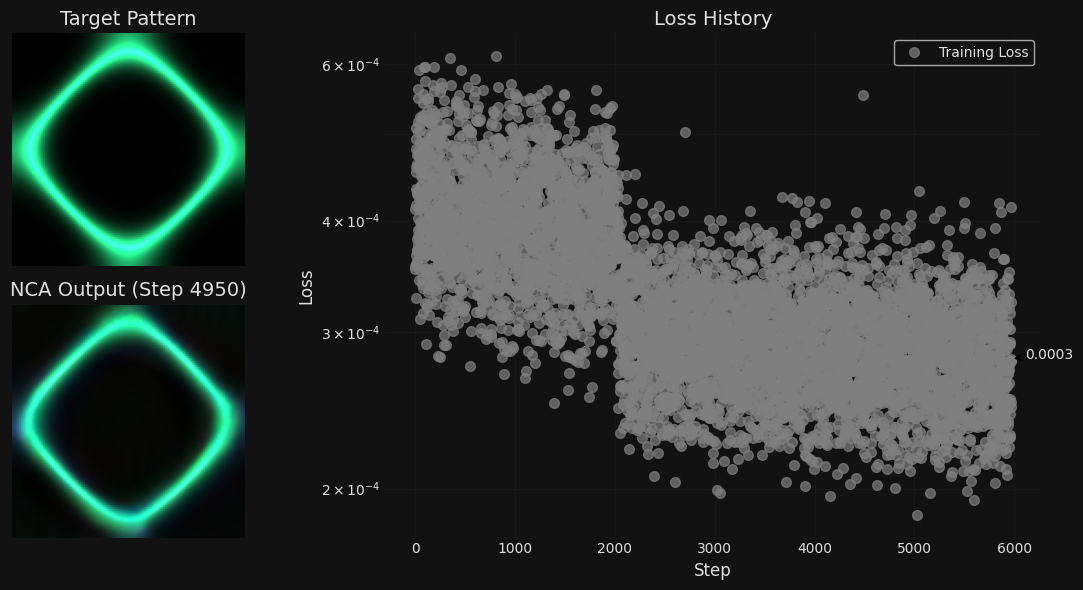

In [7]:
def mag_phase_loss(pred, target):
    pred_fft = torch.fft.rfft2(pred, norm='forward')
    target_fft = torch.fft.rfft2(target, norm='forward')

    loss_mag = (pred_fft.abs() - target_fft.abs()).abs().mean()
    loss_complex = (pred_fft - target_fft).abs().mean()

    return loss_mag + loss_complex


for i in range(5000):

    step_n = np.random.randint(64, 96)
    delta_t = step_n / 60.

    with torch.no_grad():
      batch_idx = np.random.choice(len(pool), BS, replace=False)
      x = pool[batch_idx].to(DEVICE)
      ts = times[batch_idx]
      # x = ca.seed(BS, SZ)

      if i % 16 == 0:
        x[:1] = ca.seed(1, SZ)

      x[:2,:3, ...] = get_targets(SZ, ts[:2]).to(DEVICE) - .5

    for _ in range(step_n):
      x = ca(x)

    ts += delta_t
    target_img = get_targets(SZ, ts).to(DEVICE)

    nca_rgb = ca.to_rgb(x)

    mp_loss = mag_phase_loss(nca_rgb, target_img)

    total_loss = mp_loss

    opt.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(ca.parameters(), 1.0, foreach=True)

    opt.step()
    lr_sched.step()

    pool[batch_idx] = x.detach()
    times[batch_idx] = ts

    loss_log.append(total_loss.item())

    if i % 50 == 0:
      from IPython.display import clear_output
      clear_output(wait=True)
      print(f"Iteration: {i} | Loss: {total_loss.item():.6f} | LR: {lr_sched.get_last_lr()[0]}")
      visualize_training(target_img, nca_rgb, i, loss_log) # total_loss.item())

In [11]:
def nca_shader(res, t):
  global state
  state = ca(state)
  rgb_out = ca.to_rgb(state)

  return rgb_out[0].permute(1, 2, 0) ** 2.


with torch.no_grad():
  start_t = np.random.rand() * 10.
  print(start_t)
  state = ca.seed(1, SZ)
  state[:, :3, ...] = get_chladni_target(state.shape[-1], start_t).unsqueeze(0) -.5

  dor(nca_shader, res=256)


8.352393884991539


In [ ]:
torch.save(ca, 'chladni_nca.pt')